In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid
from attn_bench.plotting.heatmap import plot_models_heatmap_panel, plot_heatmap_per_model_panel

# Attention types
Compare memorization among main attention families:
- full
- learnable sink
- gated
- linear (gdn)
- sliding window (tba)


## Main inference results

### Load memorization results

In [11]:
MAIN_MODELS = ['full-scf8', 'gated-scf8', 'learn-sink-scf8', 'gdn']

MAIN_OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000, 3000]
MAIN_PREFIXES = [25, 50, 100, 250, 500, 1000, 1500, 2000, 3000]
MAIN_SUFFIXES = [25, 50, 75, 100, 150, 250, 500, 750, 1000]

main_results_grid = load_mem_results_scores_grid(
    MAIN_OFFSETS, MAIN_PREFIXES, MAIN_SUFFIXES, models=MAIN_MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

### Rouge-L

#### Offsets

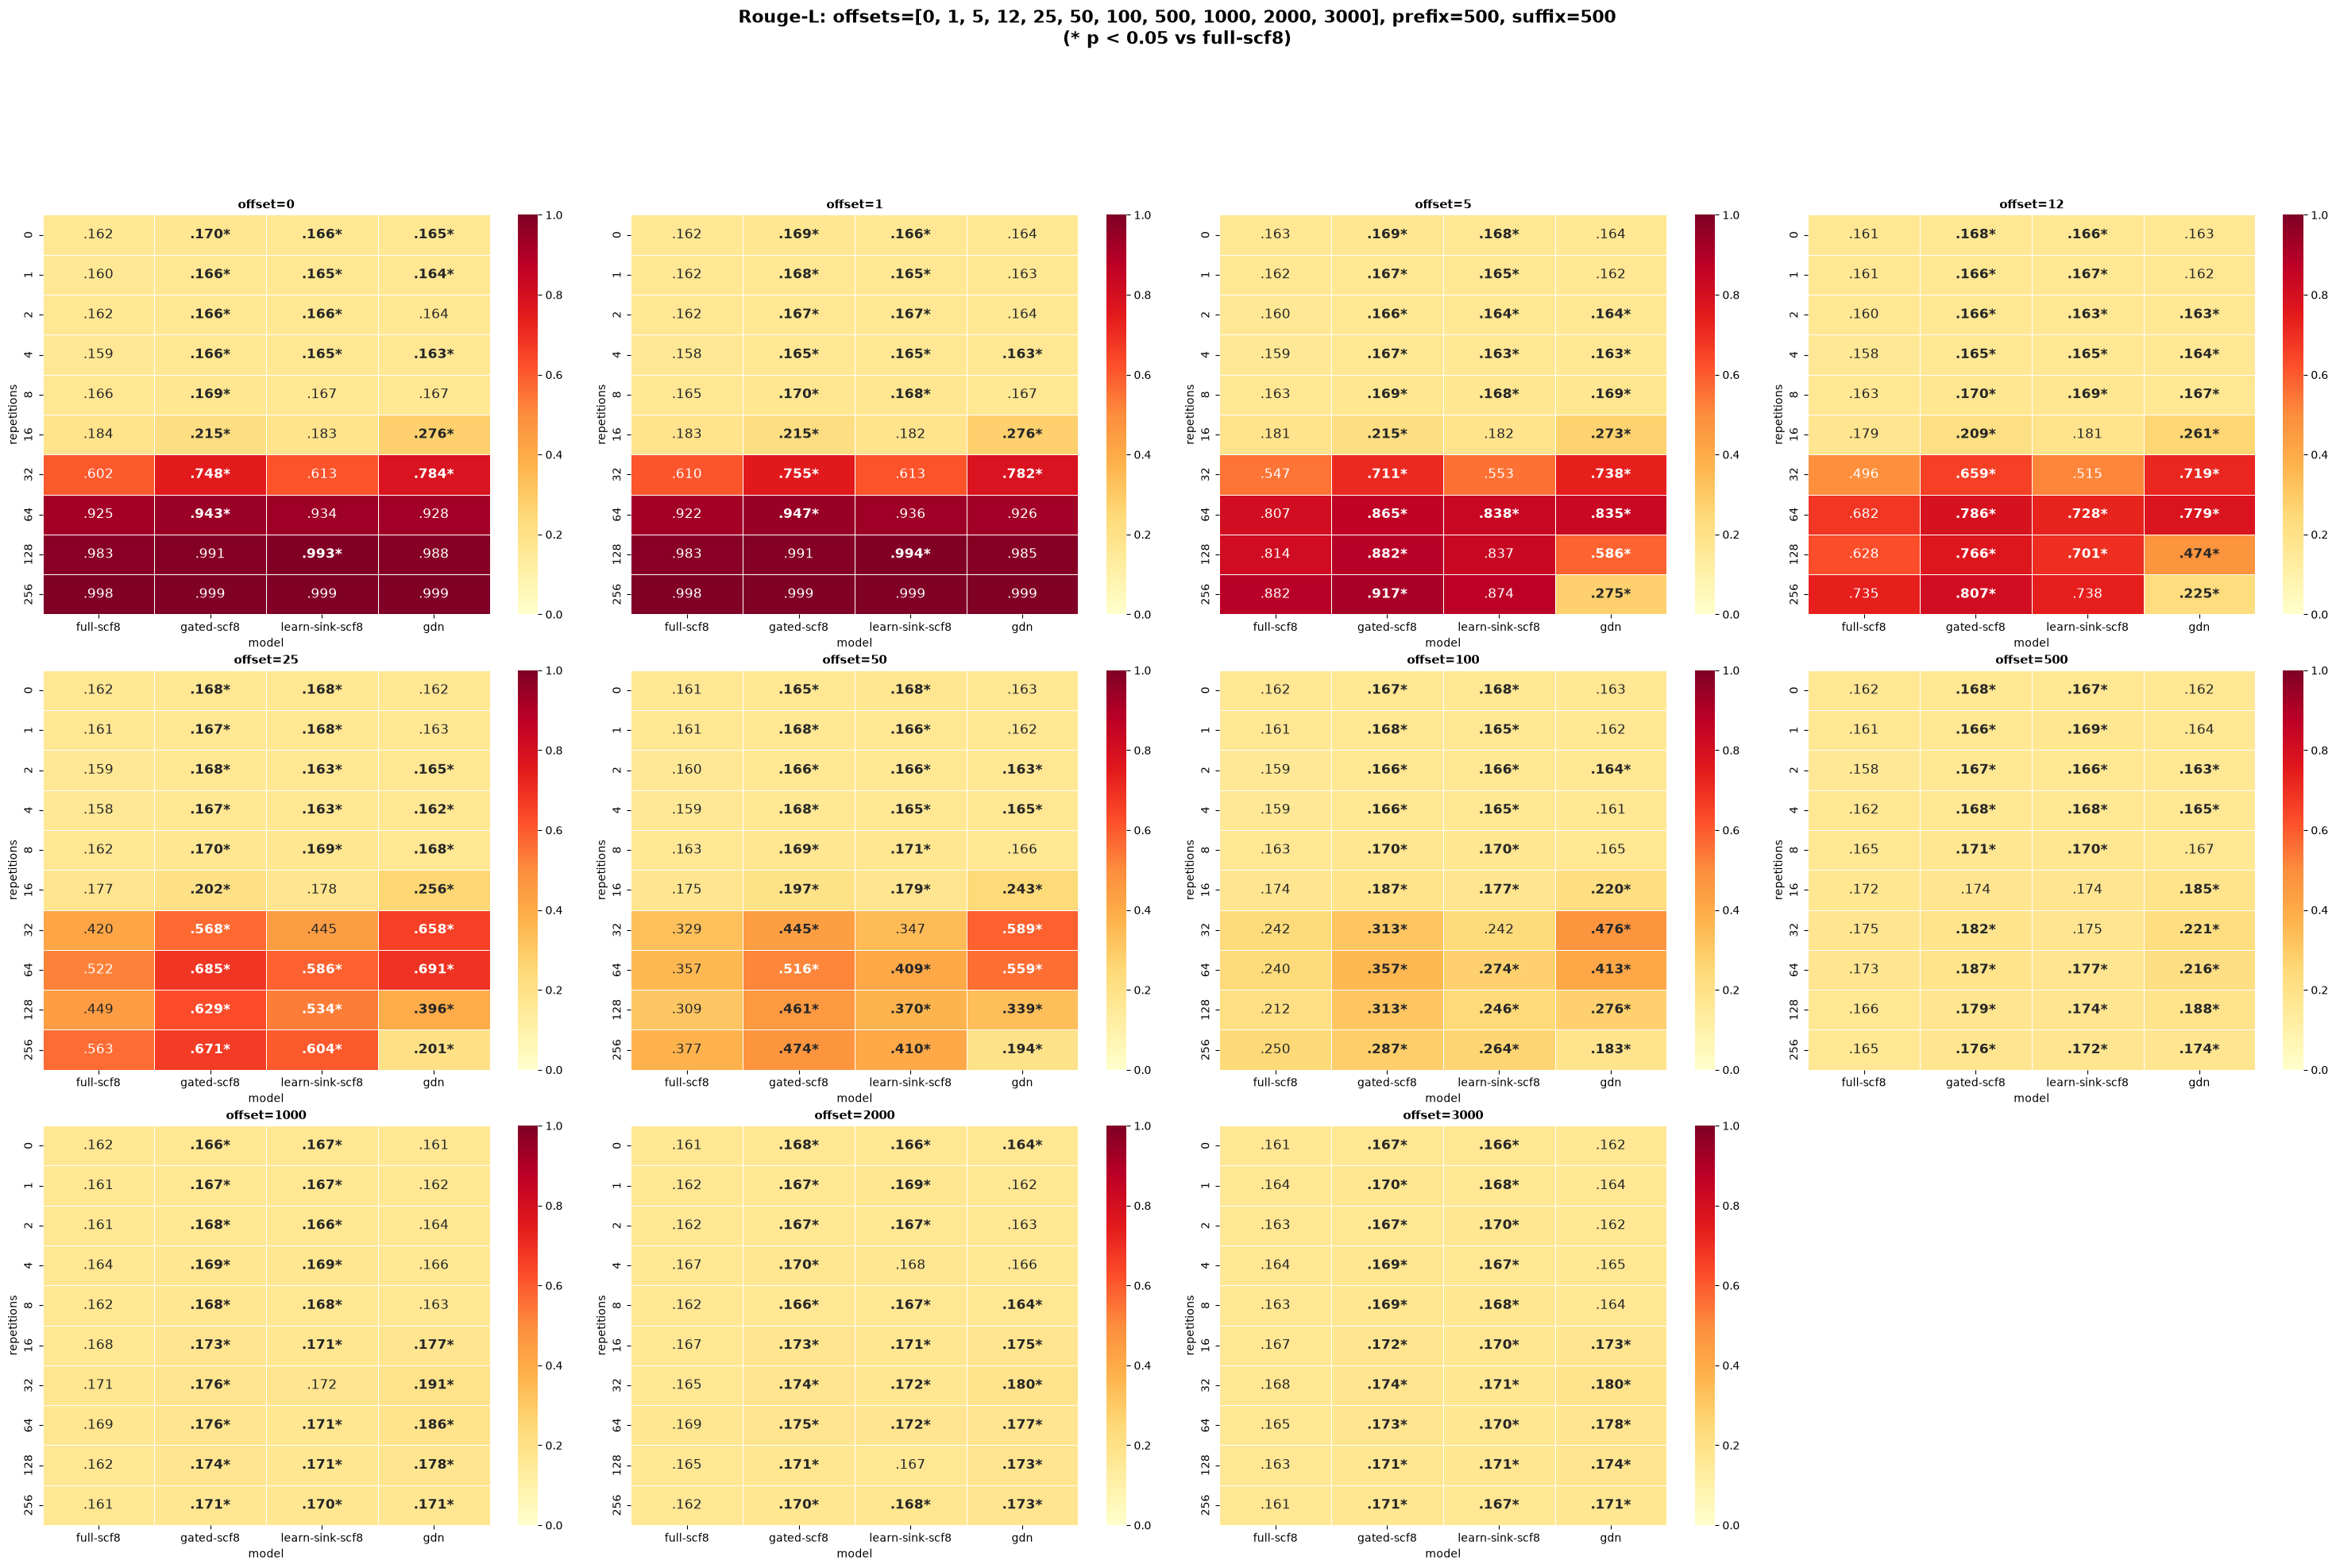

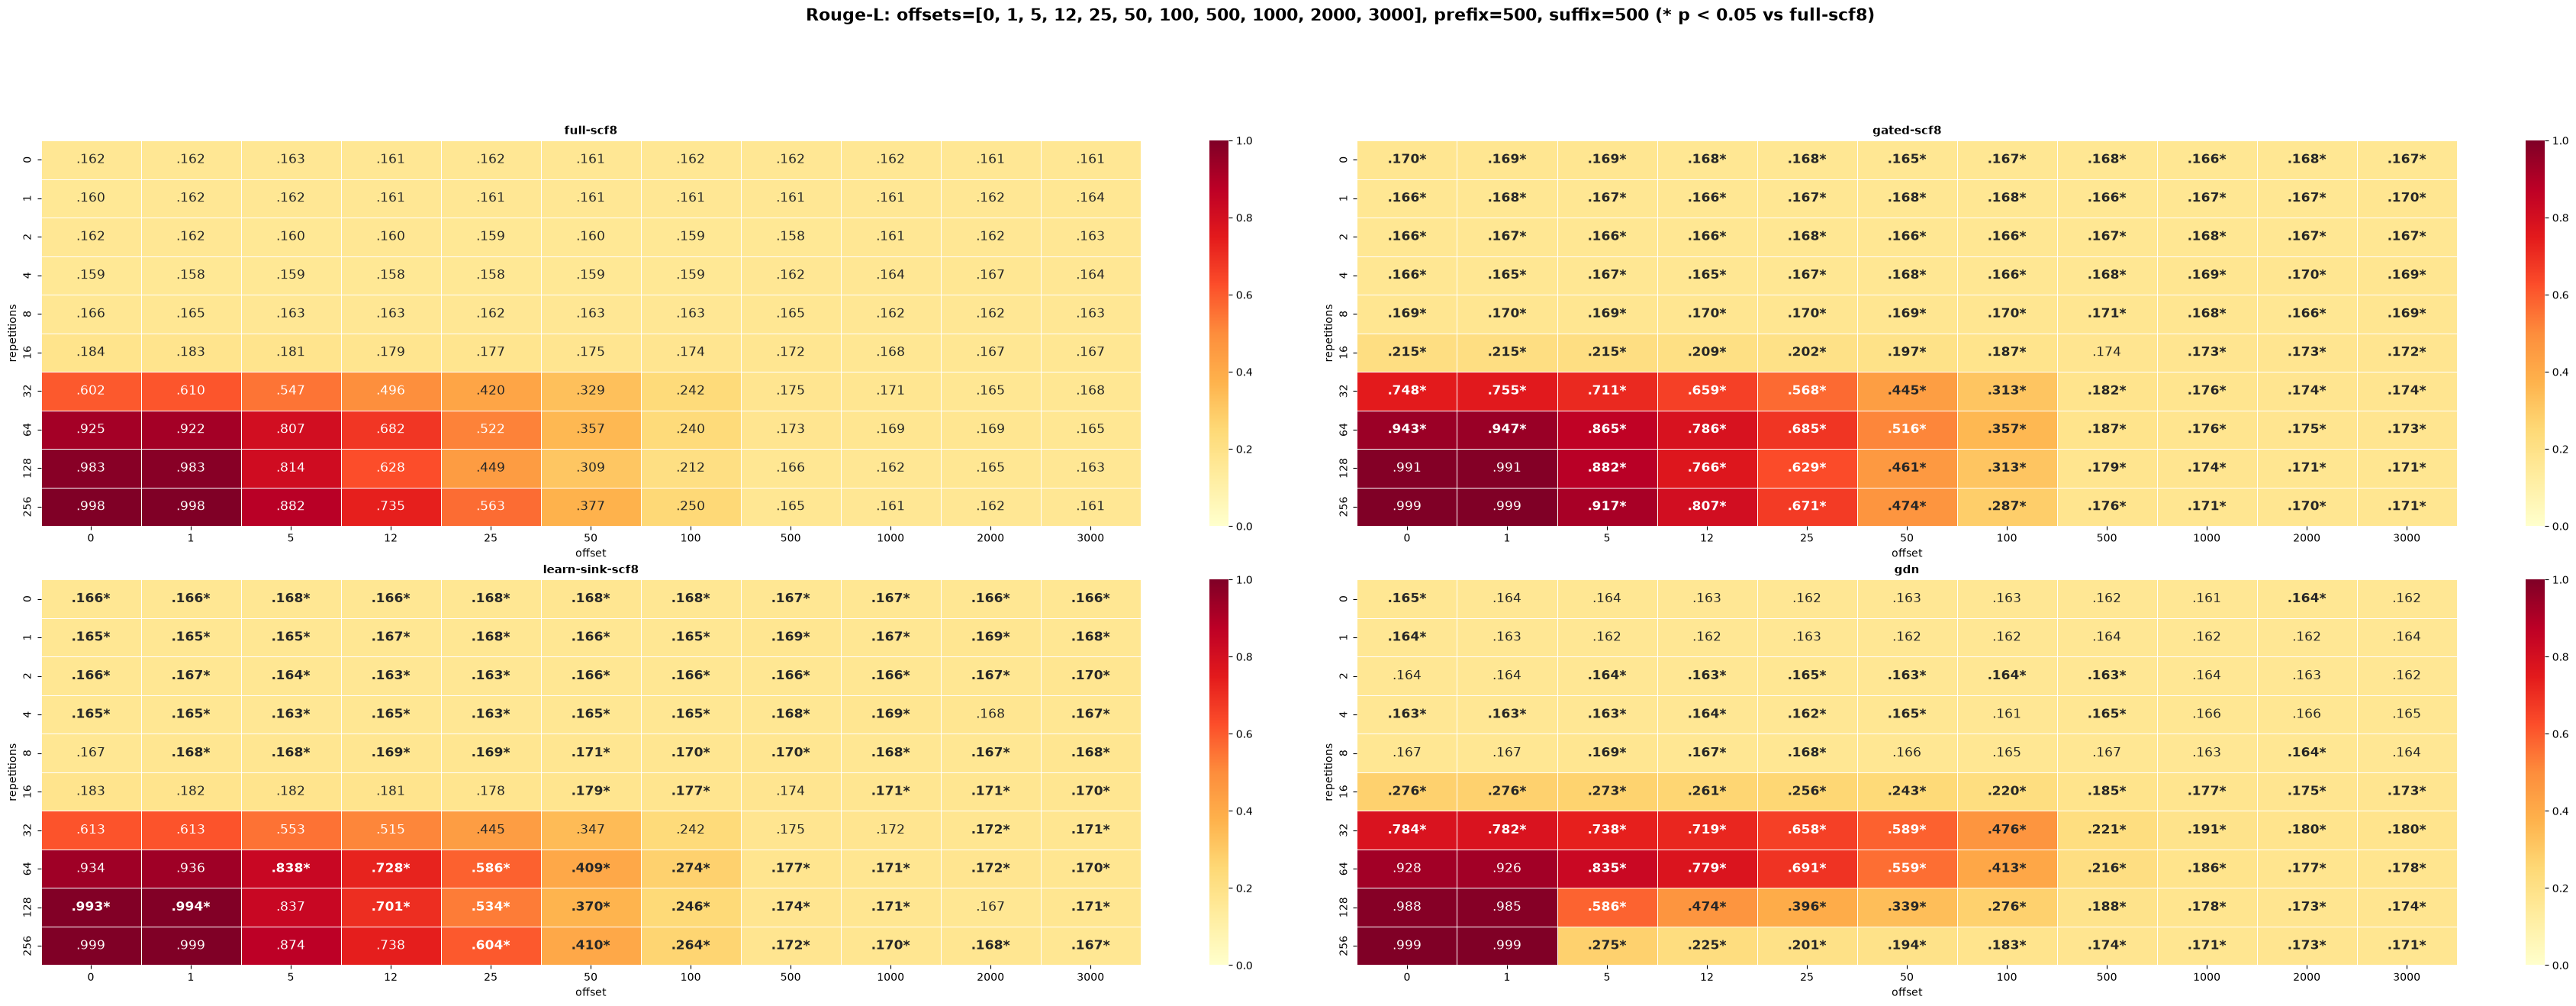

In [12]:
plot_models_heatmap_panel(
    main_results_grid, 'Rouge-L', panels='offset', values=MAIN_OFFSETS, fixed_prefix=500, fixed_suffix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS,
)
plot_heatmap_per_model_panel(
    main_results_grid, 'Rouge-L', columns='offset', values=MAIN_OFFSETS, fixed_prefix=500, fixed_suffix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS, ncols=2
)

#### Prefixes

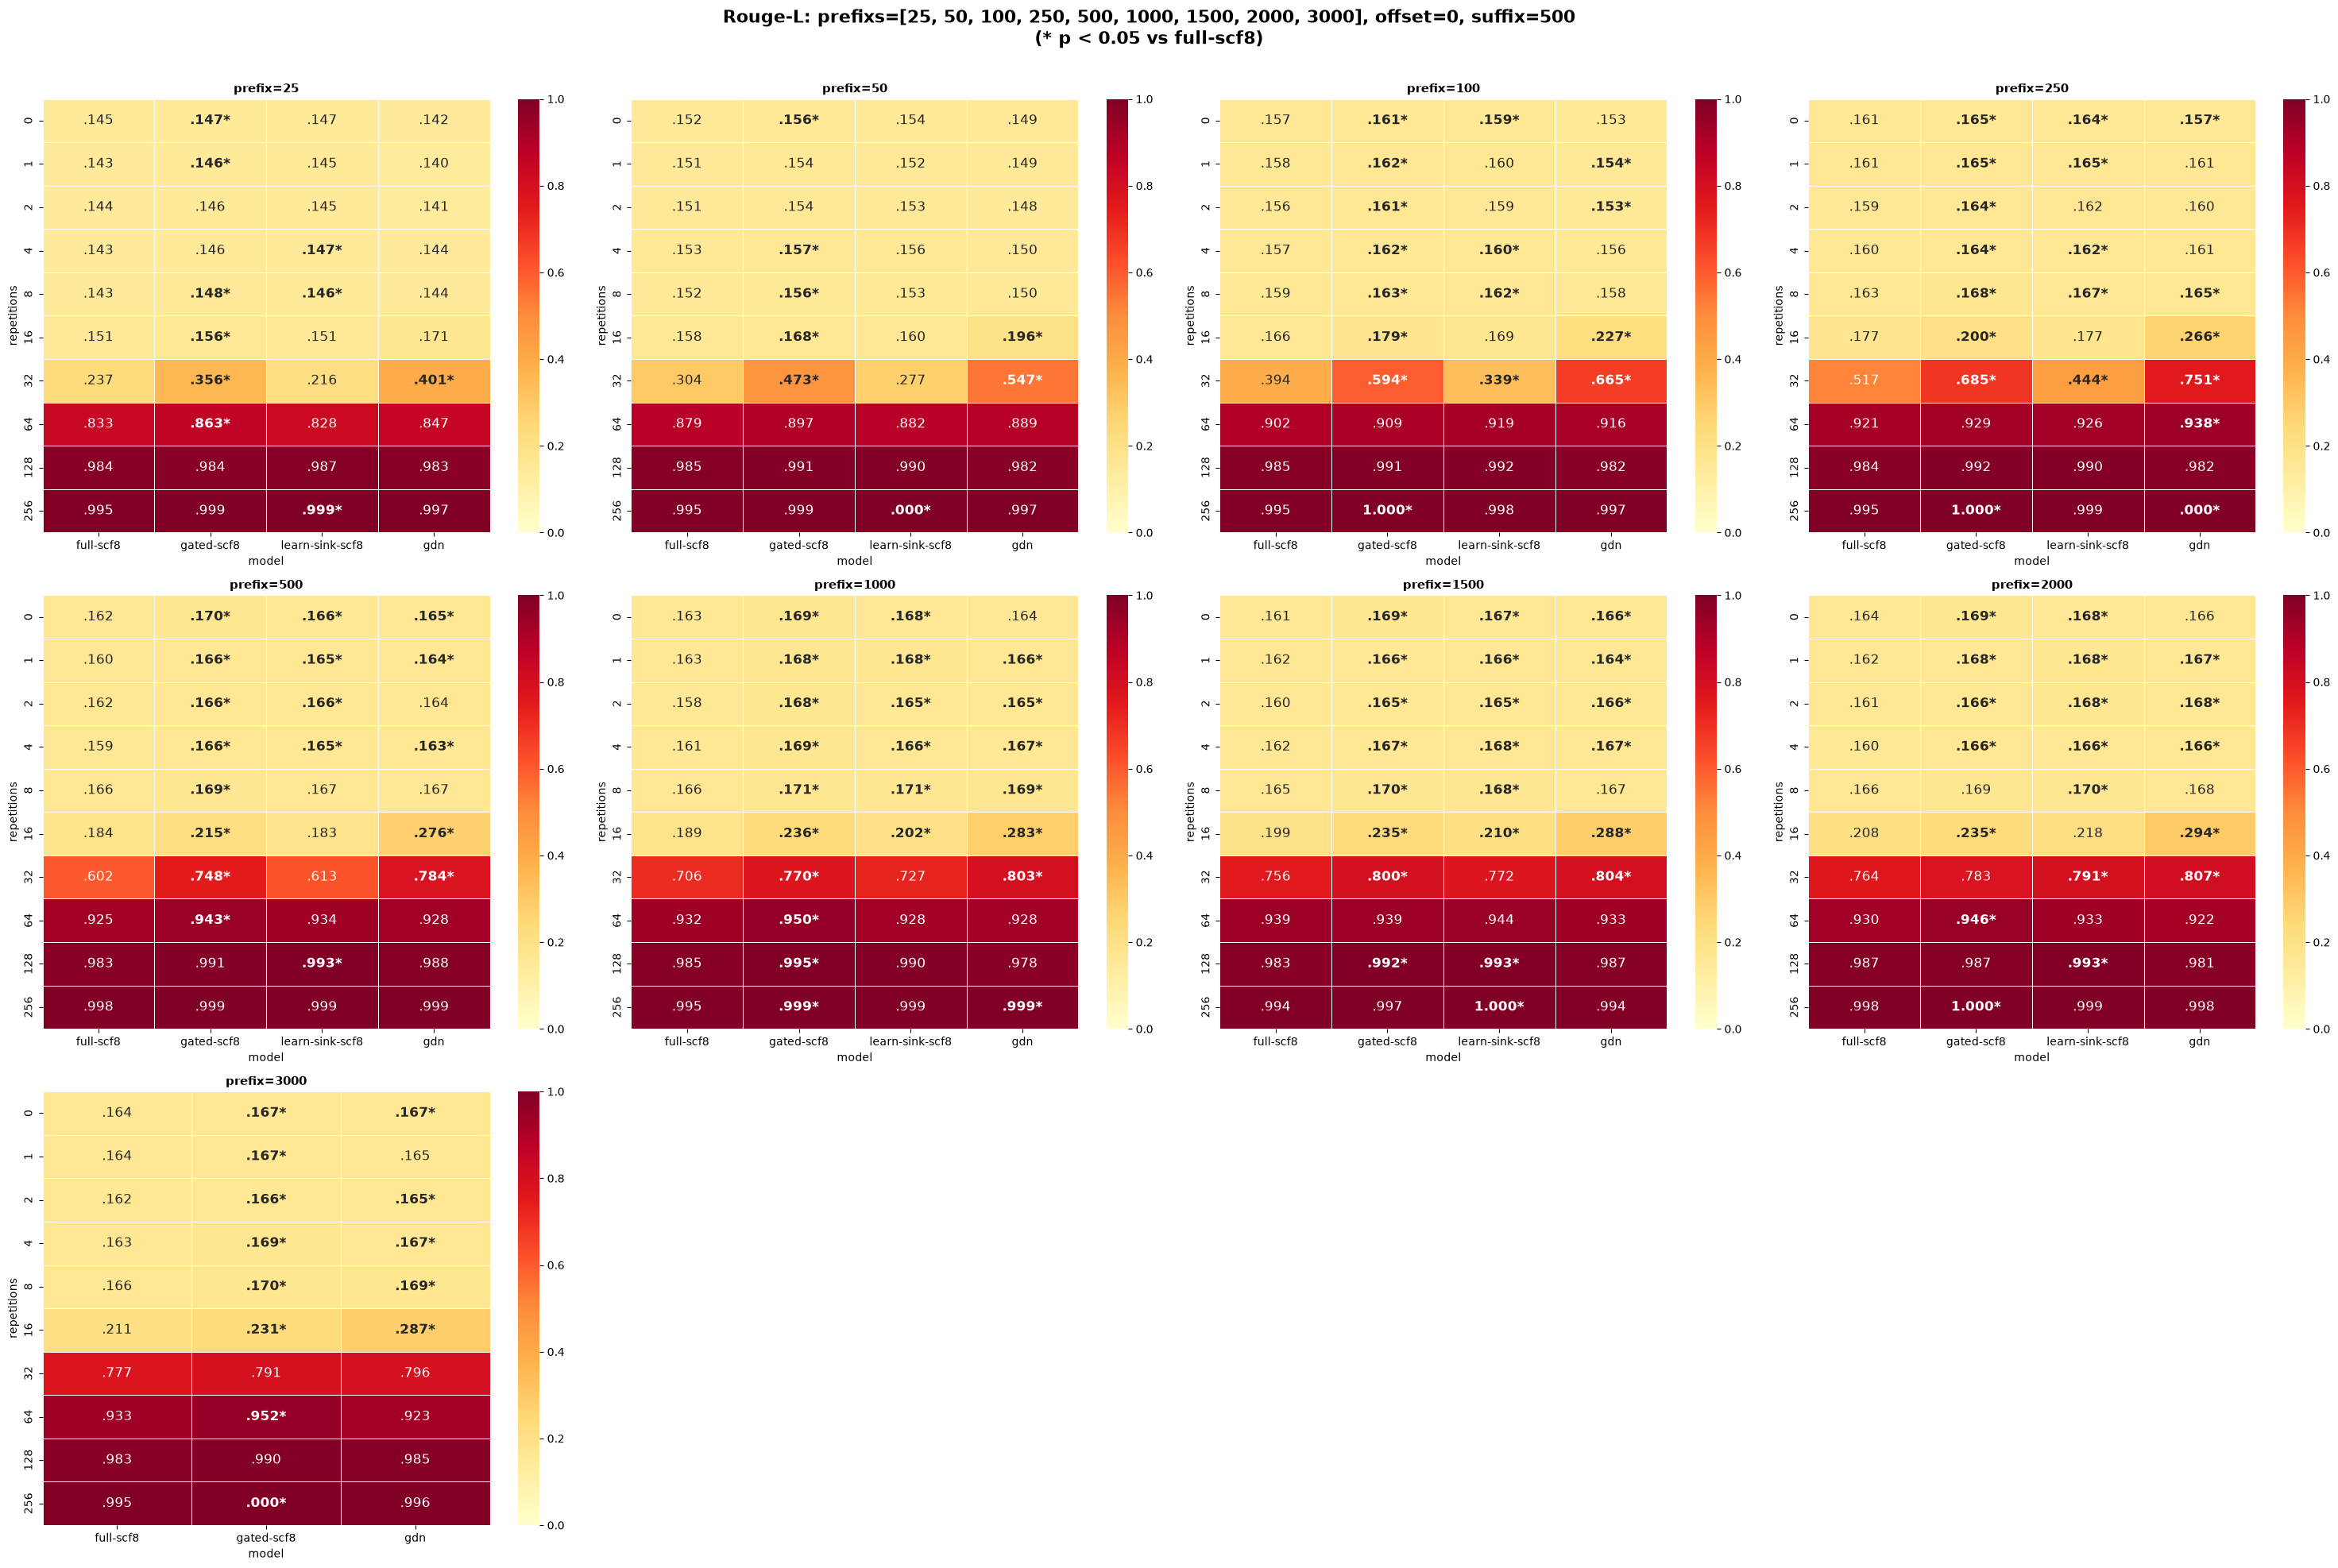

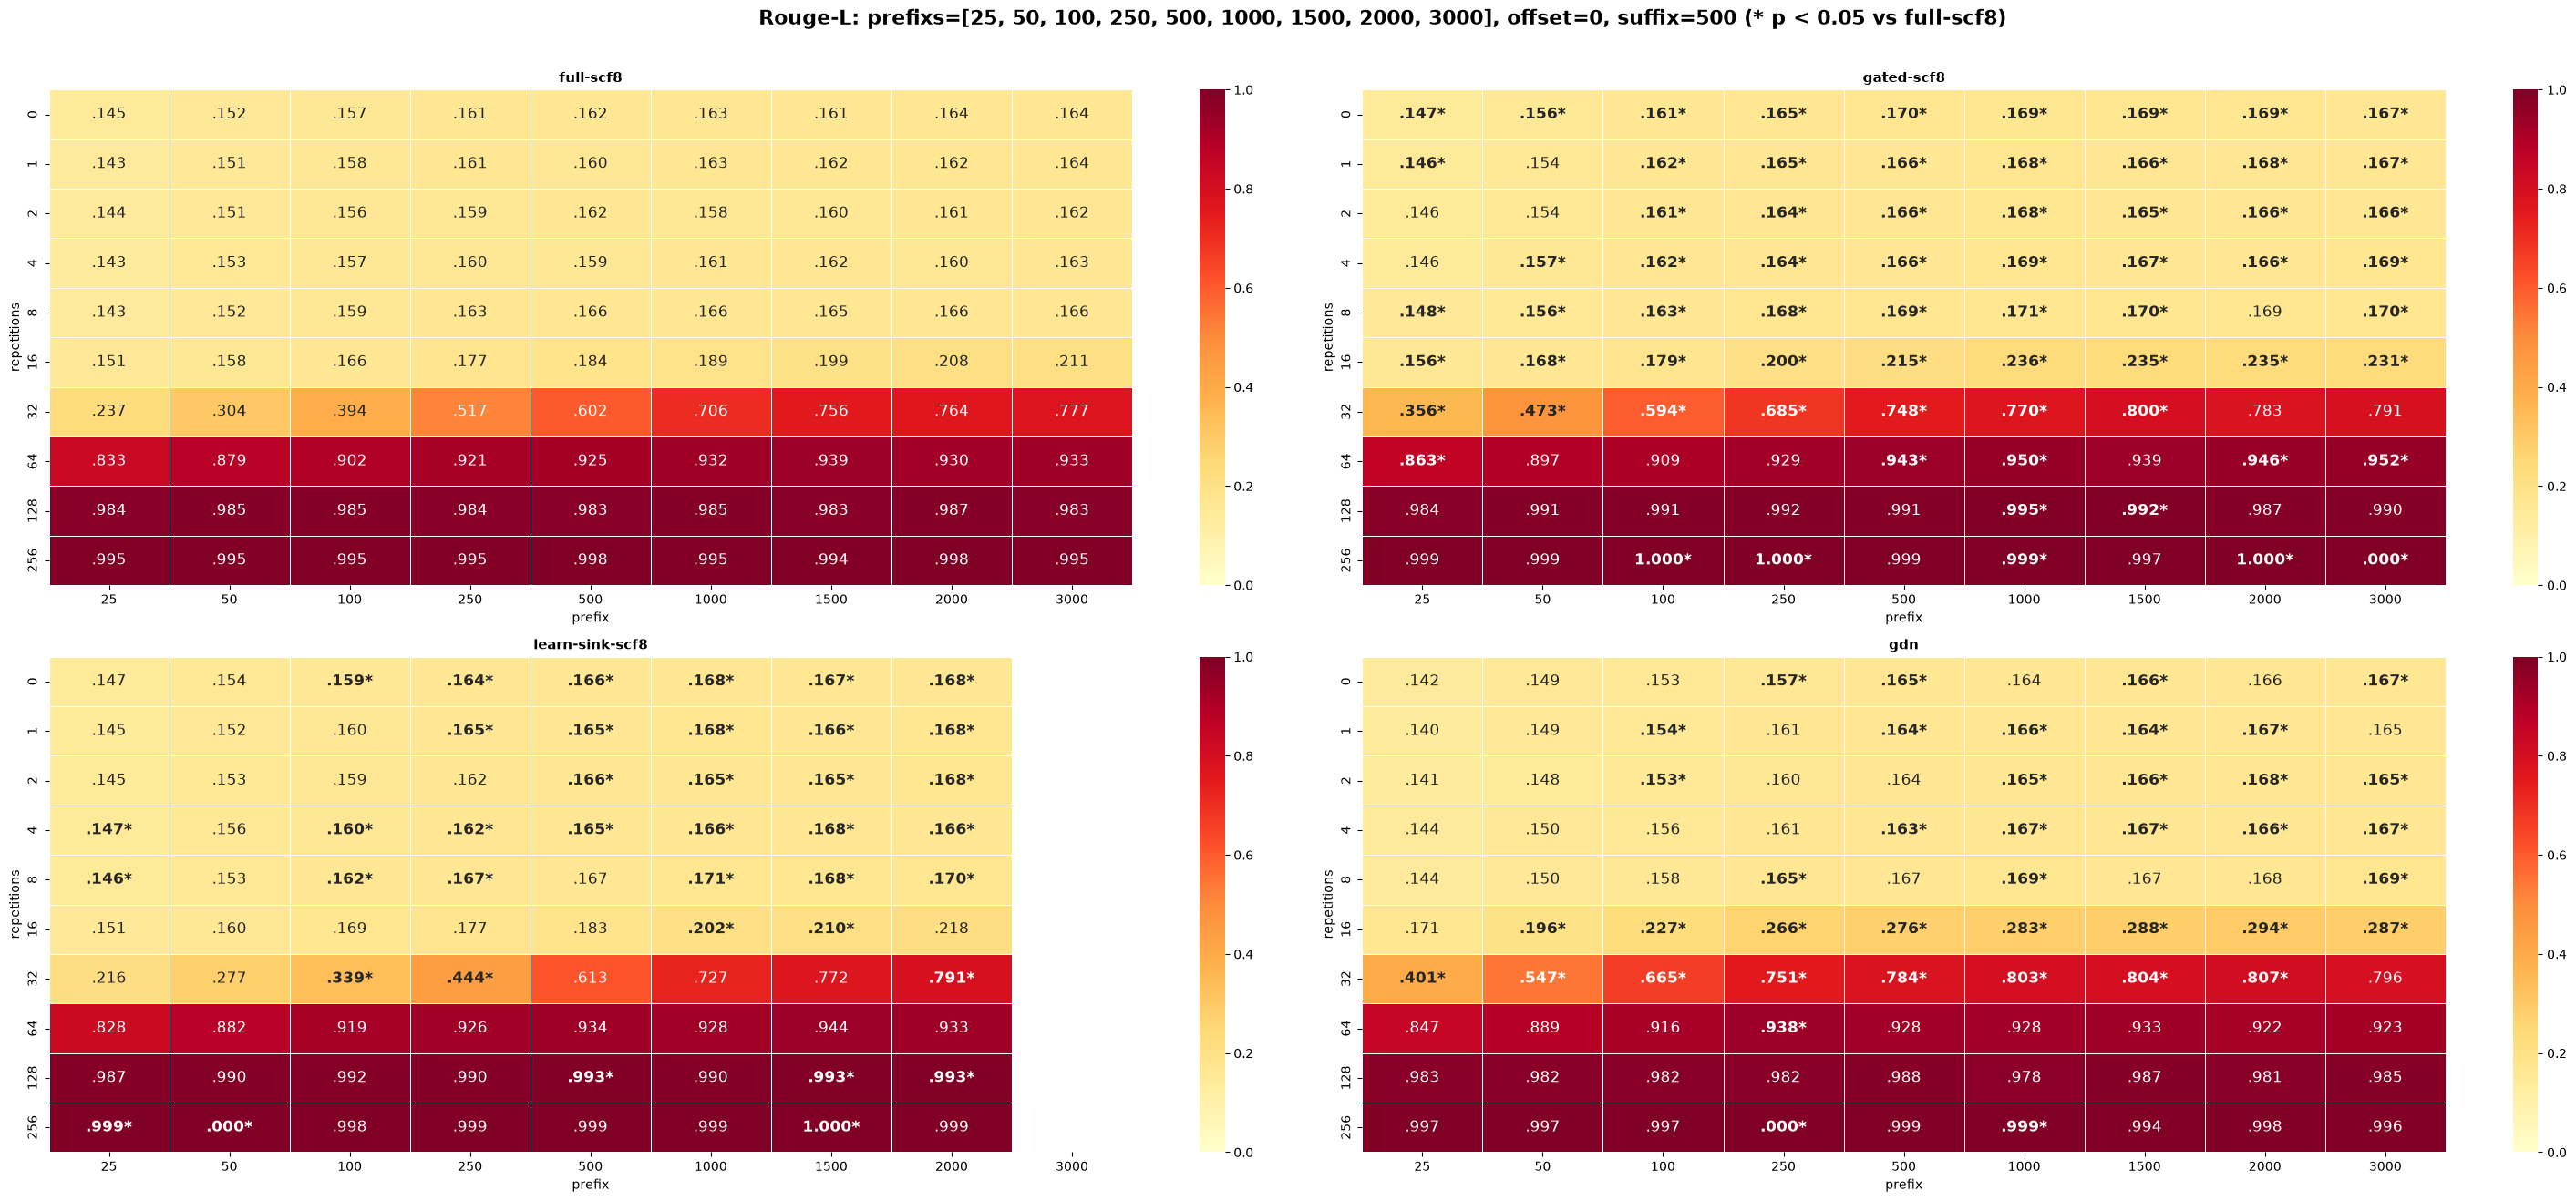

In [5]:
plot_models_heatmap_panel(
    main_results_grid, 'Rouge-L', panels='prefix', values=MAIN_PREFIXES, fixed_offset=0, fixed_suffix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS, ncols=4
)
plot_heatmap_per_model_panel(
    main_results_grid, 'Rouge-L', columns='prefix', values=MAIN_PREFIXES, fixed_offset=0, fixed_suffix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS, ncols=2
)

#### Suffixes

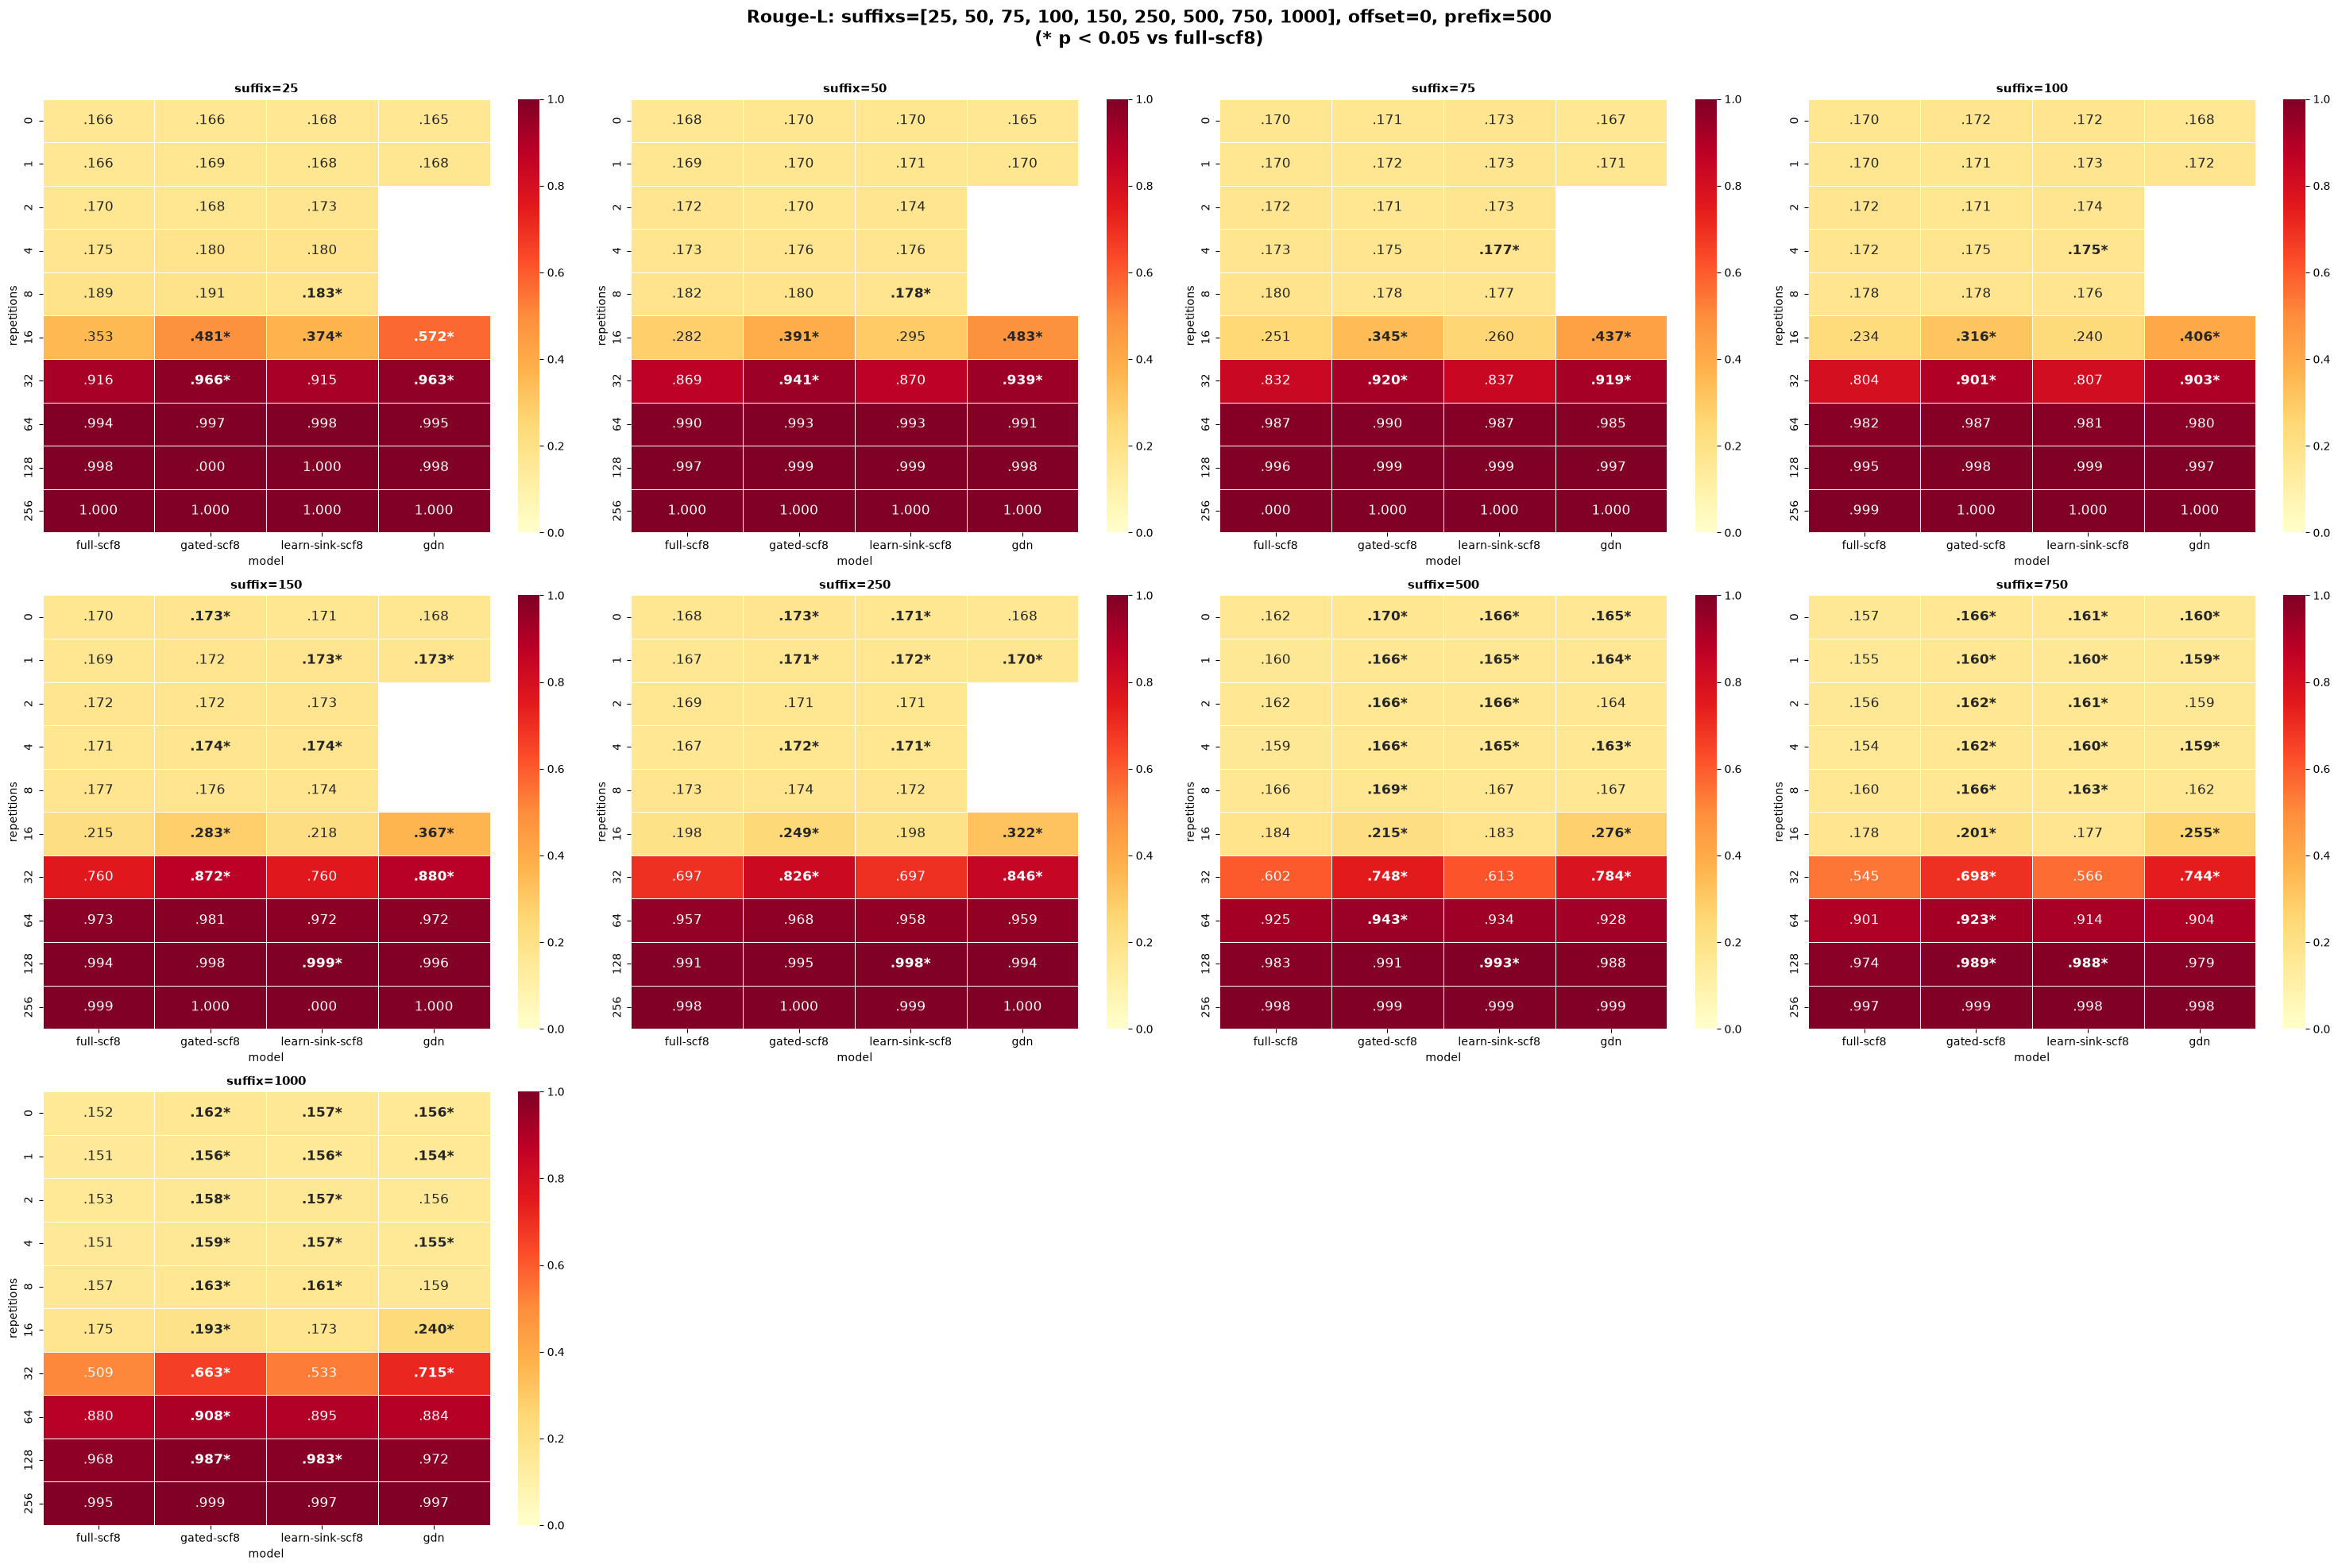

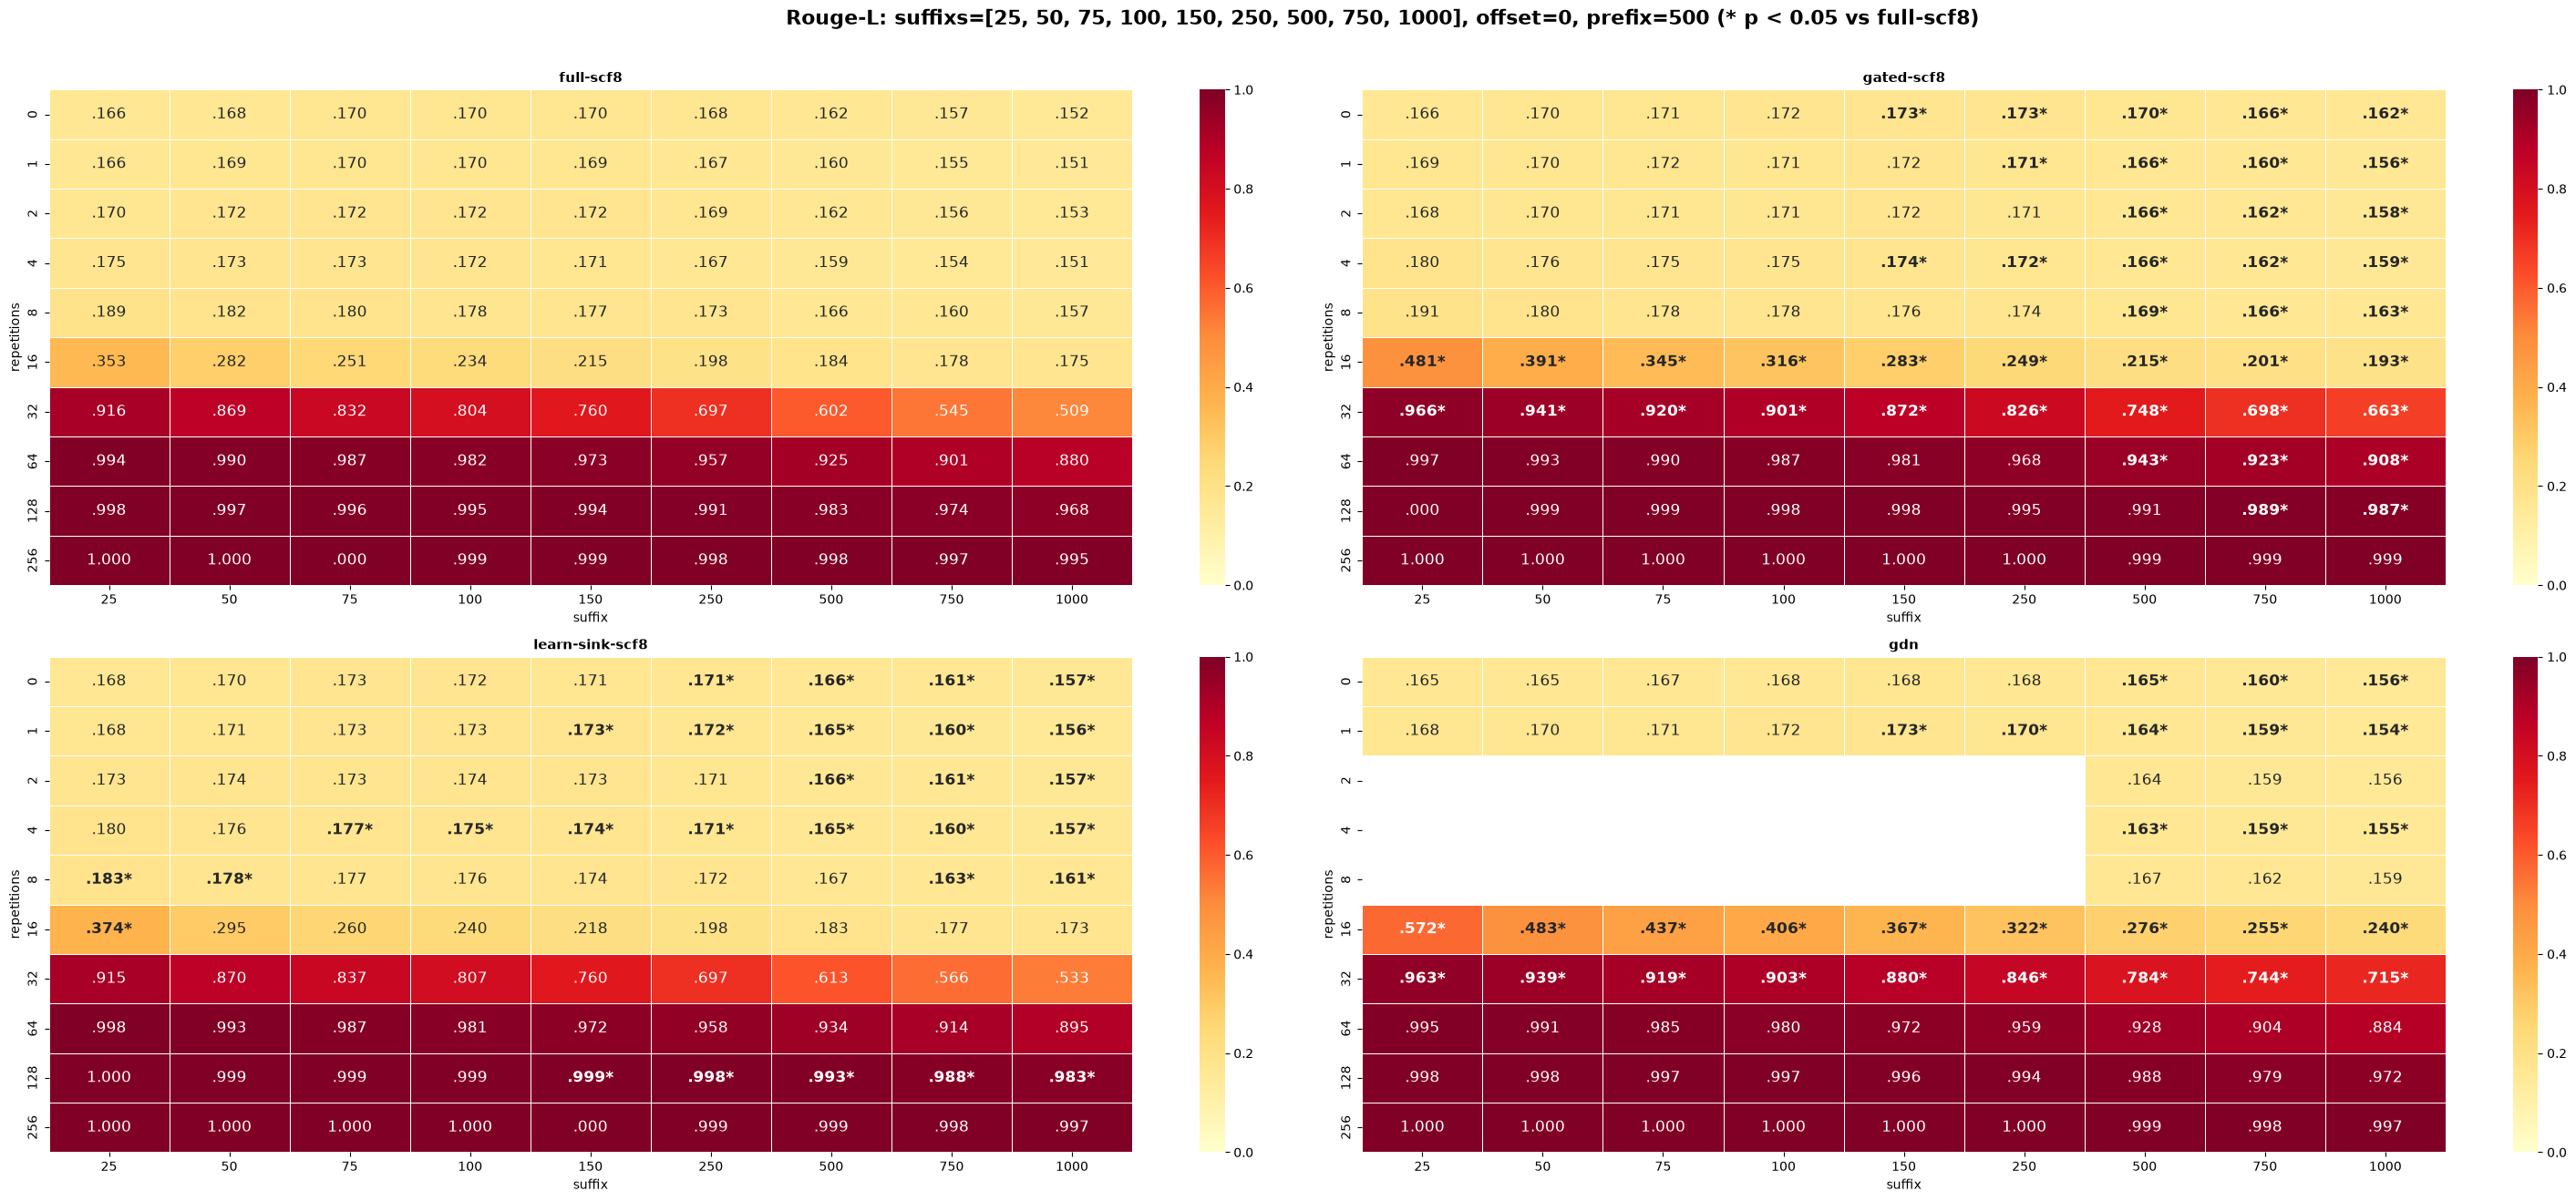

In [6]:
plot_models_heatmap_panel(
    main_results_grid, 'Rouge-L', panels='suffix', values=MAIN_SUFFIXES, fixed_offset=0, fixed_prefix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS,
)
plot_heatmap_per_model_panel(
    main_results_grid, 'Rouge-L', columns='suffix', values=MAIN_SUFFIXES, fixed_offset=0, fixed_prefix=500,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS, ncols=2
)

#### Small prefix (25), varying suffixes

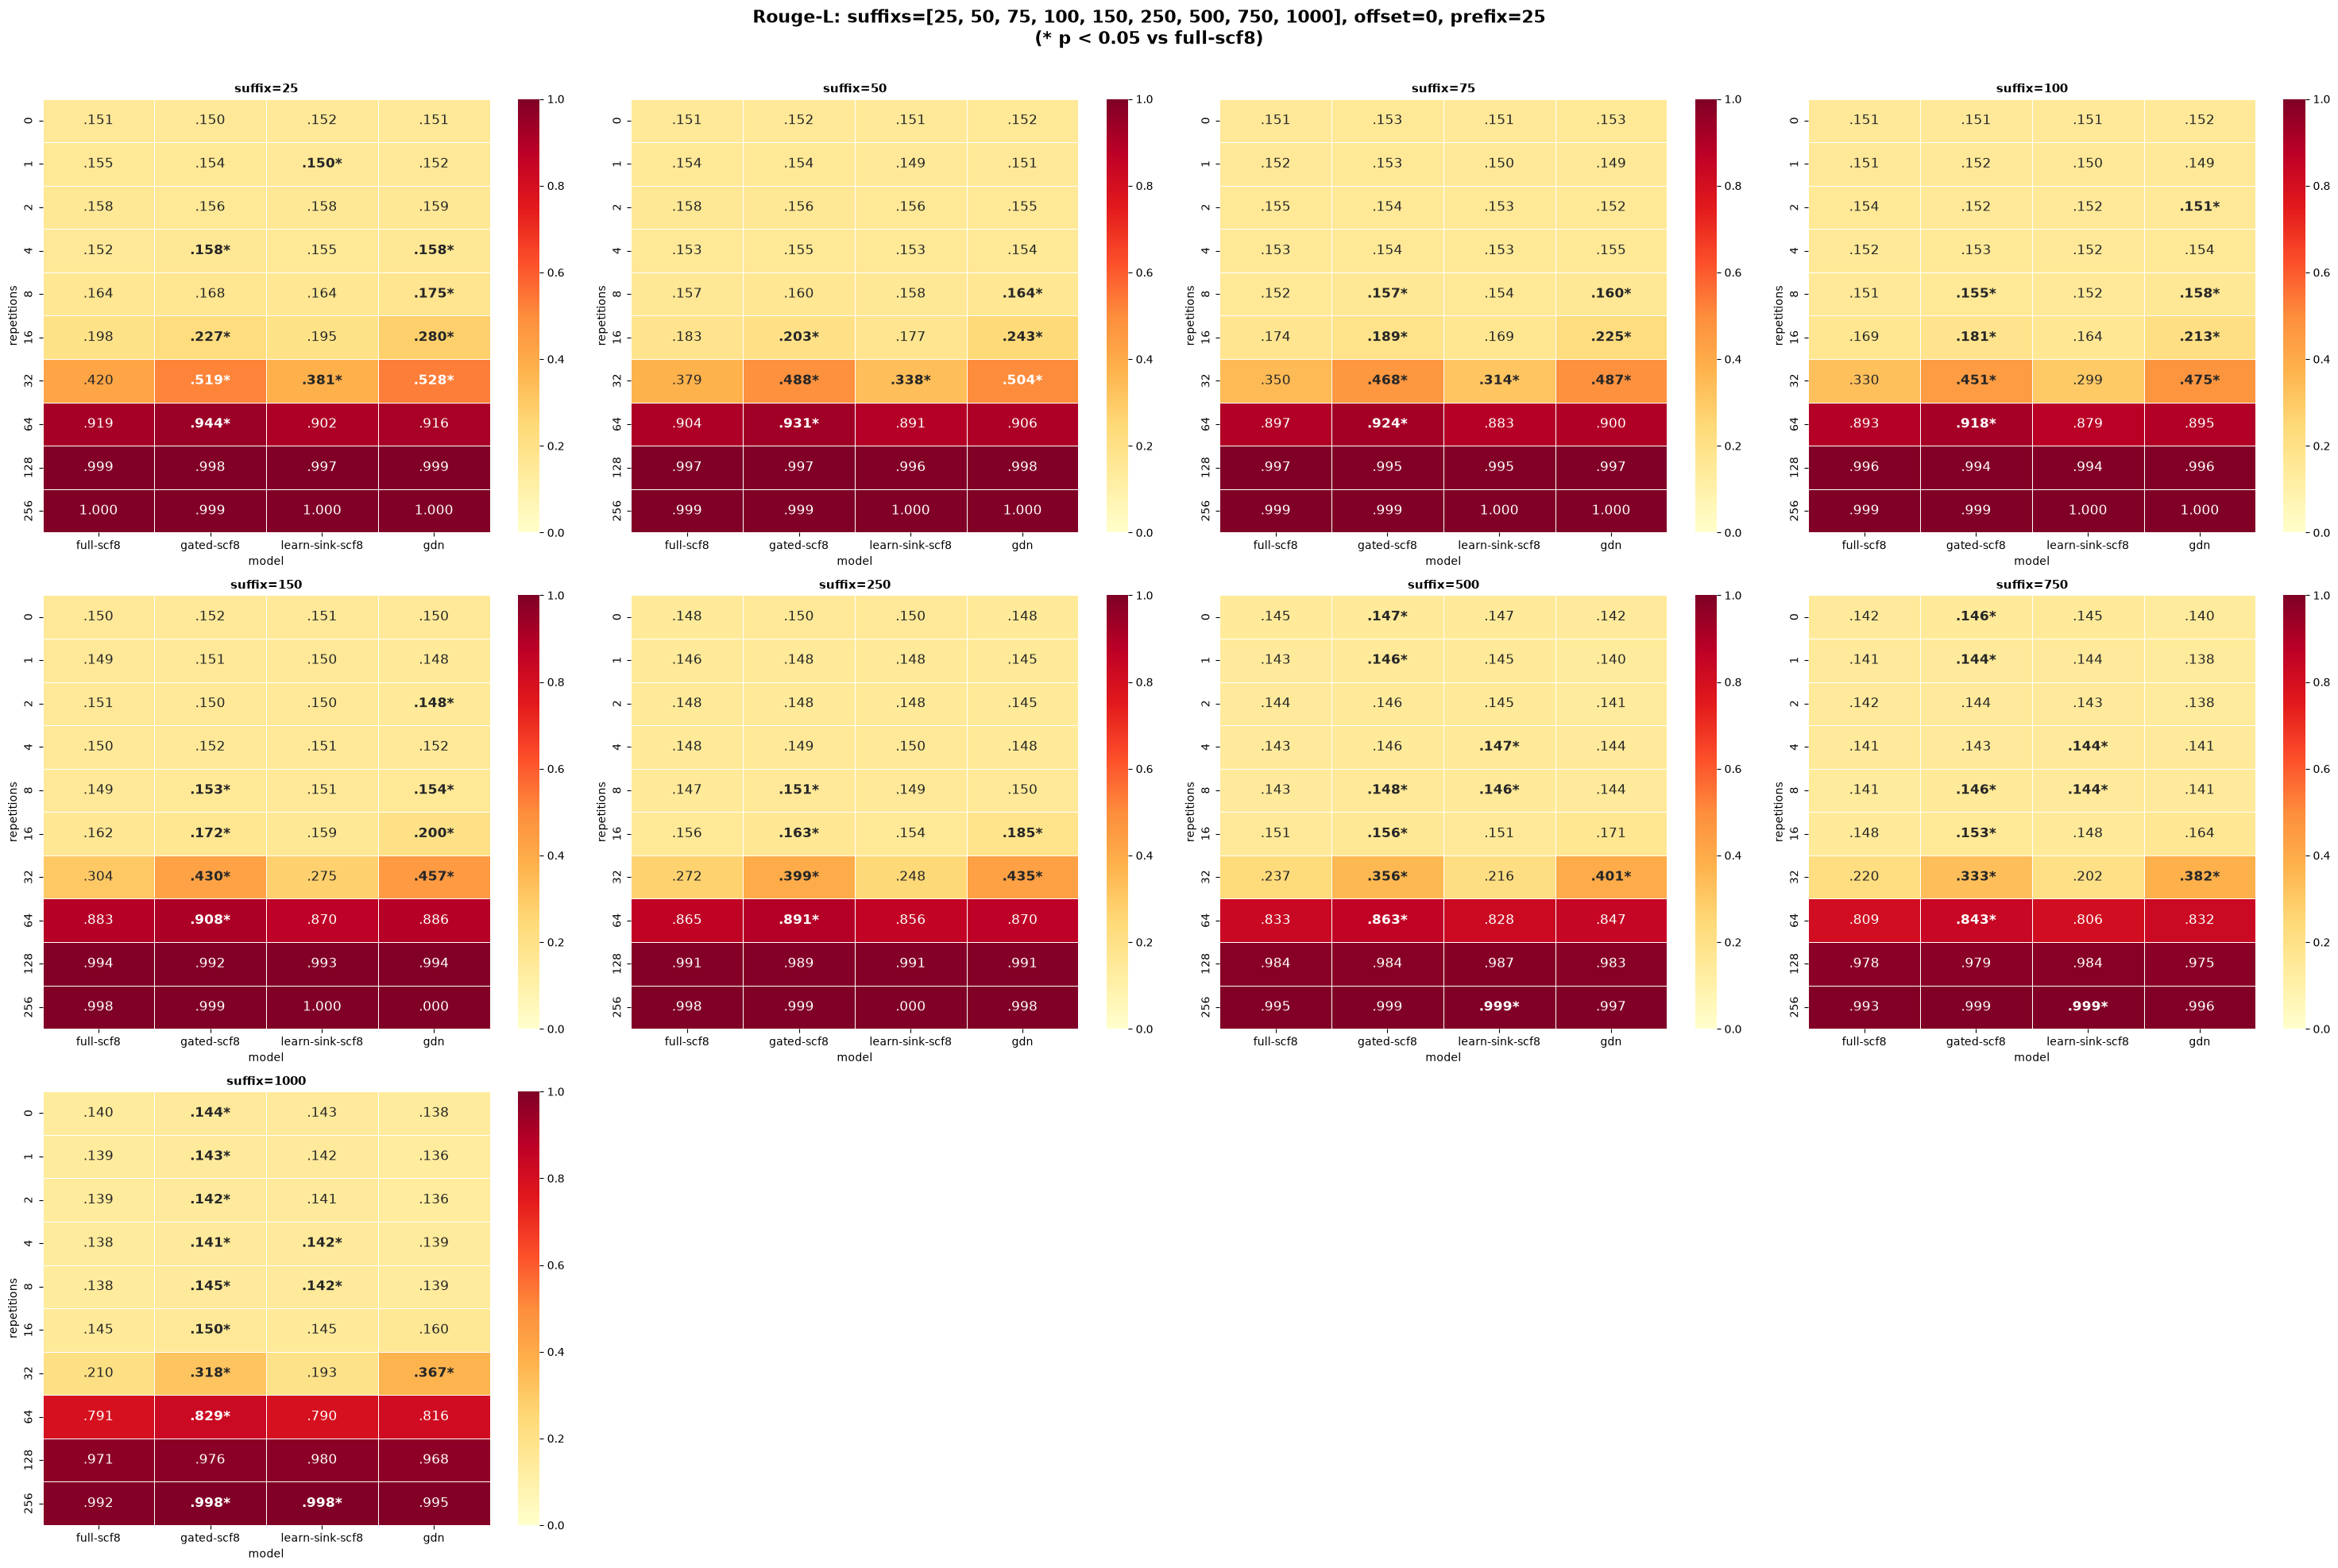

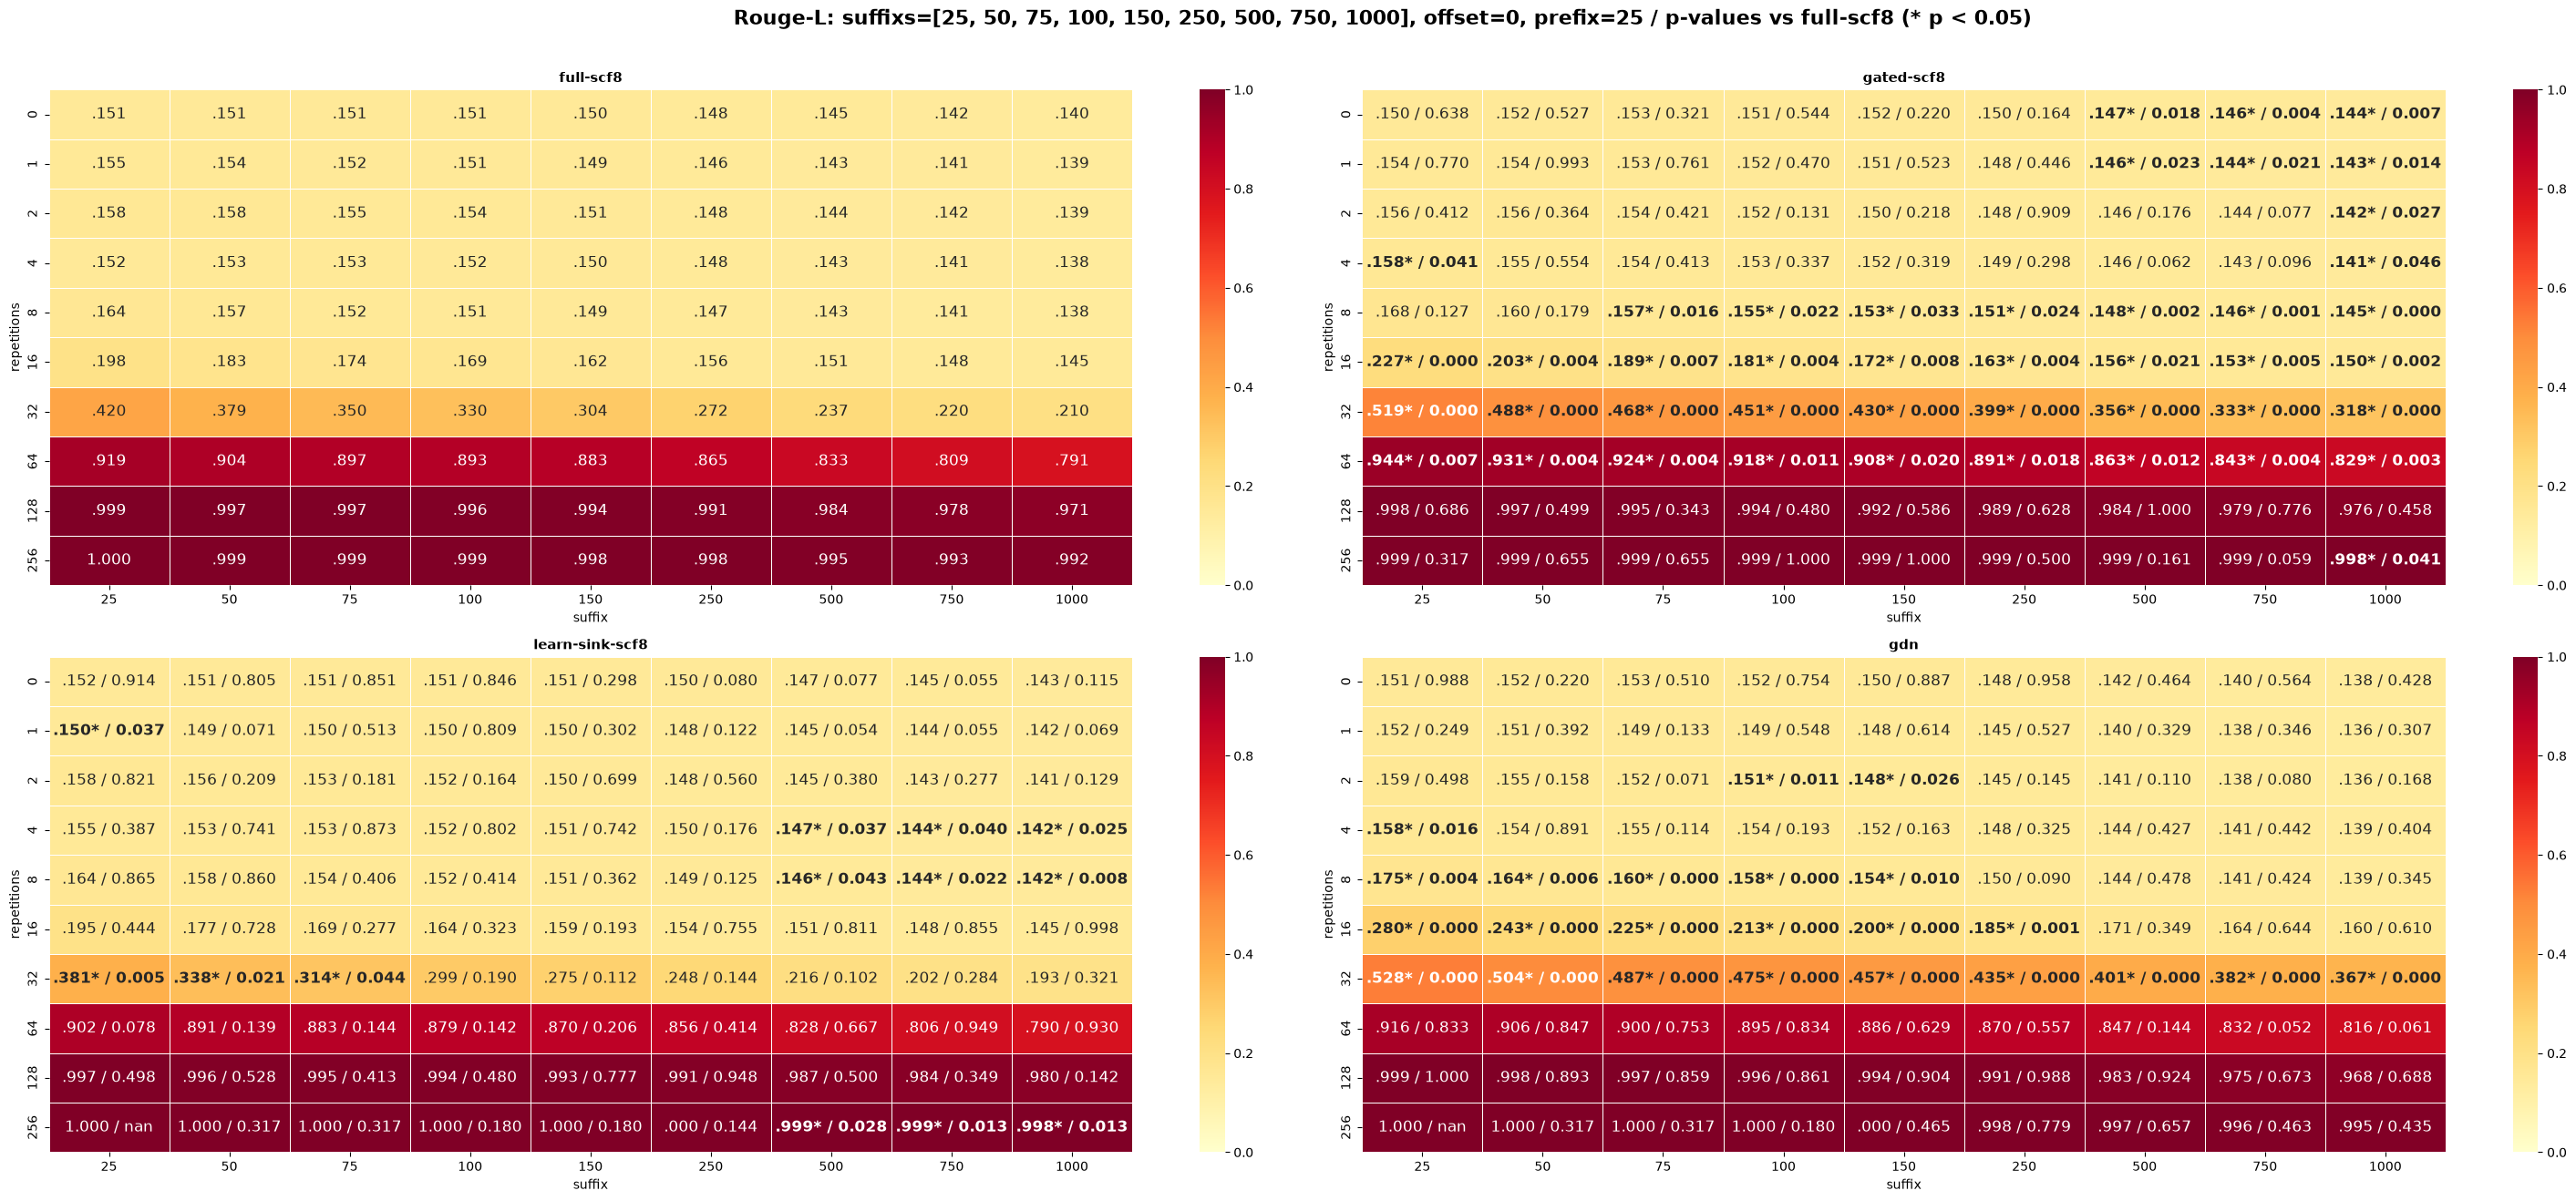

In [7]:
plot_models_heatmap_panel(
    main_results_grid, 'Rouge-L', panels='suffix', values=MAIN_SUFFIXES, fixed_offset=0, fixed_prefix=25,
    reference='full-scf8', show_pvalues=False, models=MAIN_MODELS,
)
plot_heatmap_per_model_panel(
    main_results_grid, 'Rouge-L', columns='suffix', values=MAIN_SUFFIXES, models=MAIN_MODELS,
    fixed_offset=0, fixed_prefix=25, ncols=2, reference='full-scf8'
)

#### Small prefix (25), varying suffixes: one heatmap per model

### (n, p)-discoverable extraction

Hayes et al. 2025 -- fraction of samples with `1-(1-p_z)^n >= p`. `N_P_COMBOS` is a plain
list, add/remove pairs to try other values.

In [8]:
N_P_COMBOS = [(10, 0.25), (100, 0.5)]  # Hayes et al. 2025, Fig. 6 style

#### Small prefix (25), varying suffixes

`p_z` (needed for this metric) is only backfilled at prefix=25 across the full suffix sweep --
fixing a small prefix and varying suffix (not prefix at fixed_suffix=500) also matches how
p_z actually behaves: getting every generated token inside the top-40 sampling set is only
plausible at short suffix boundaries.

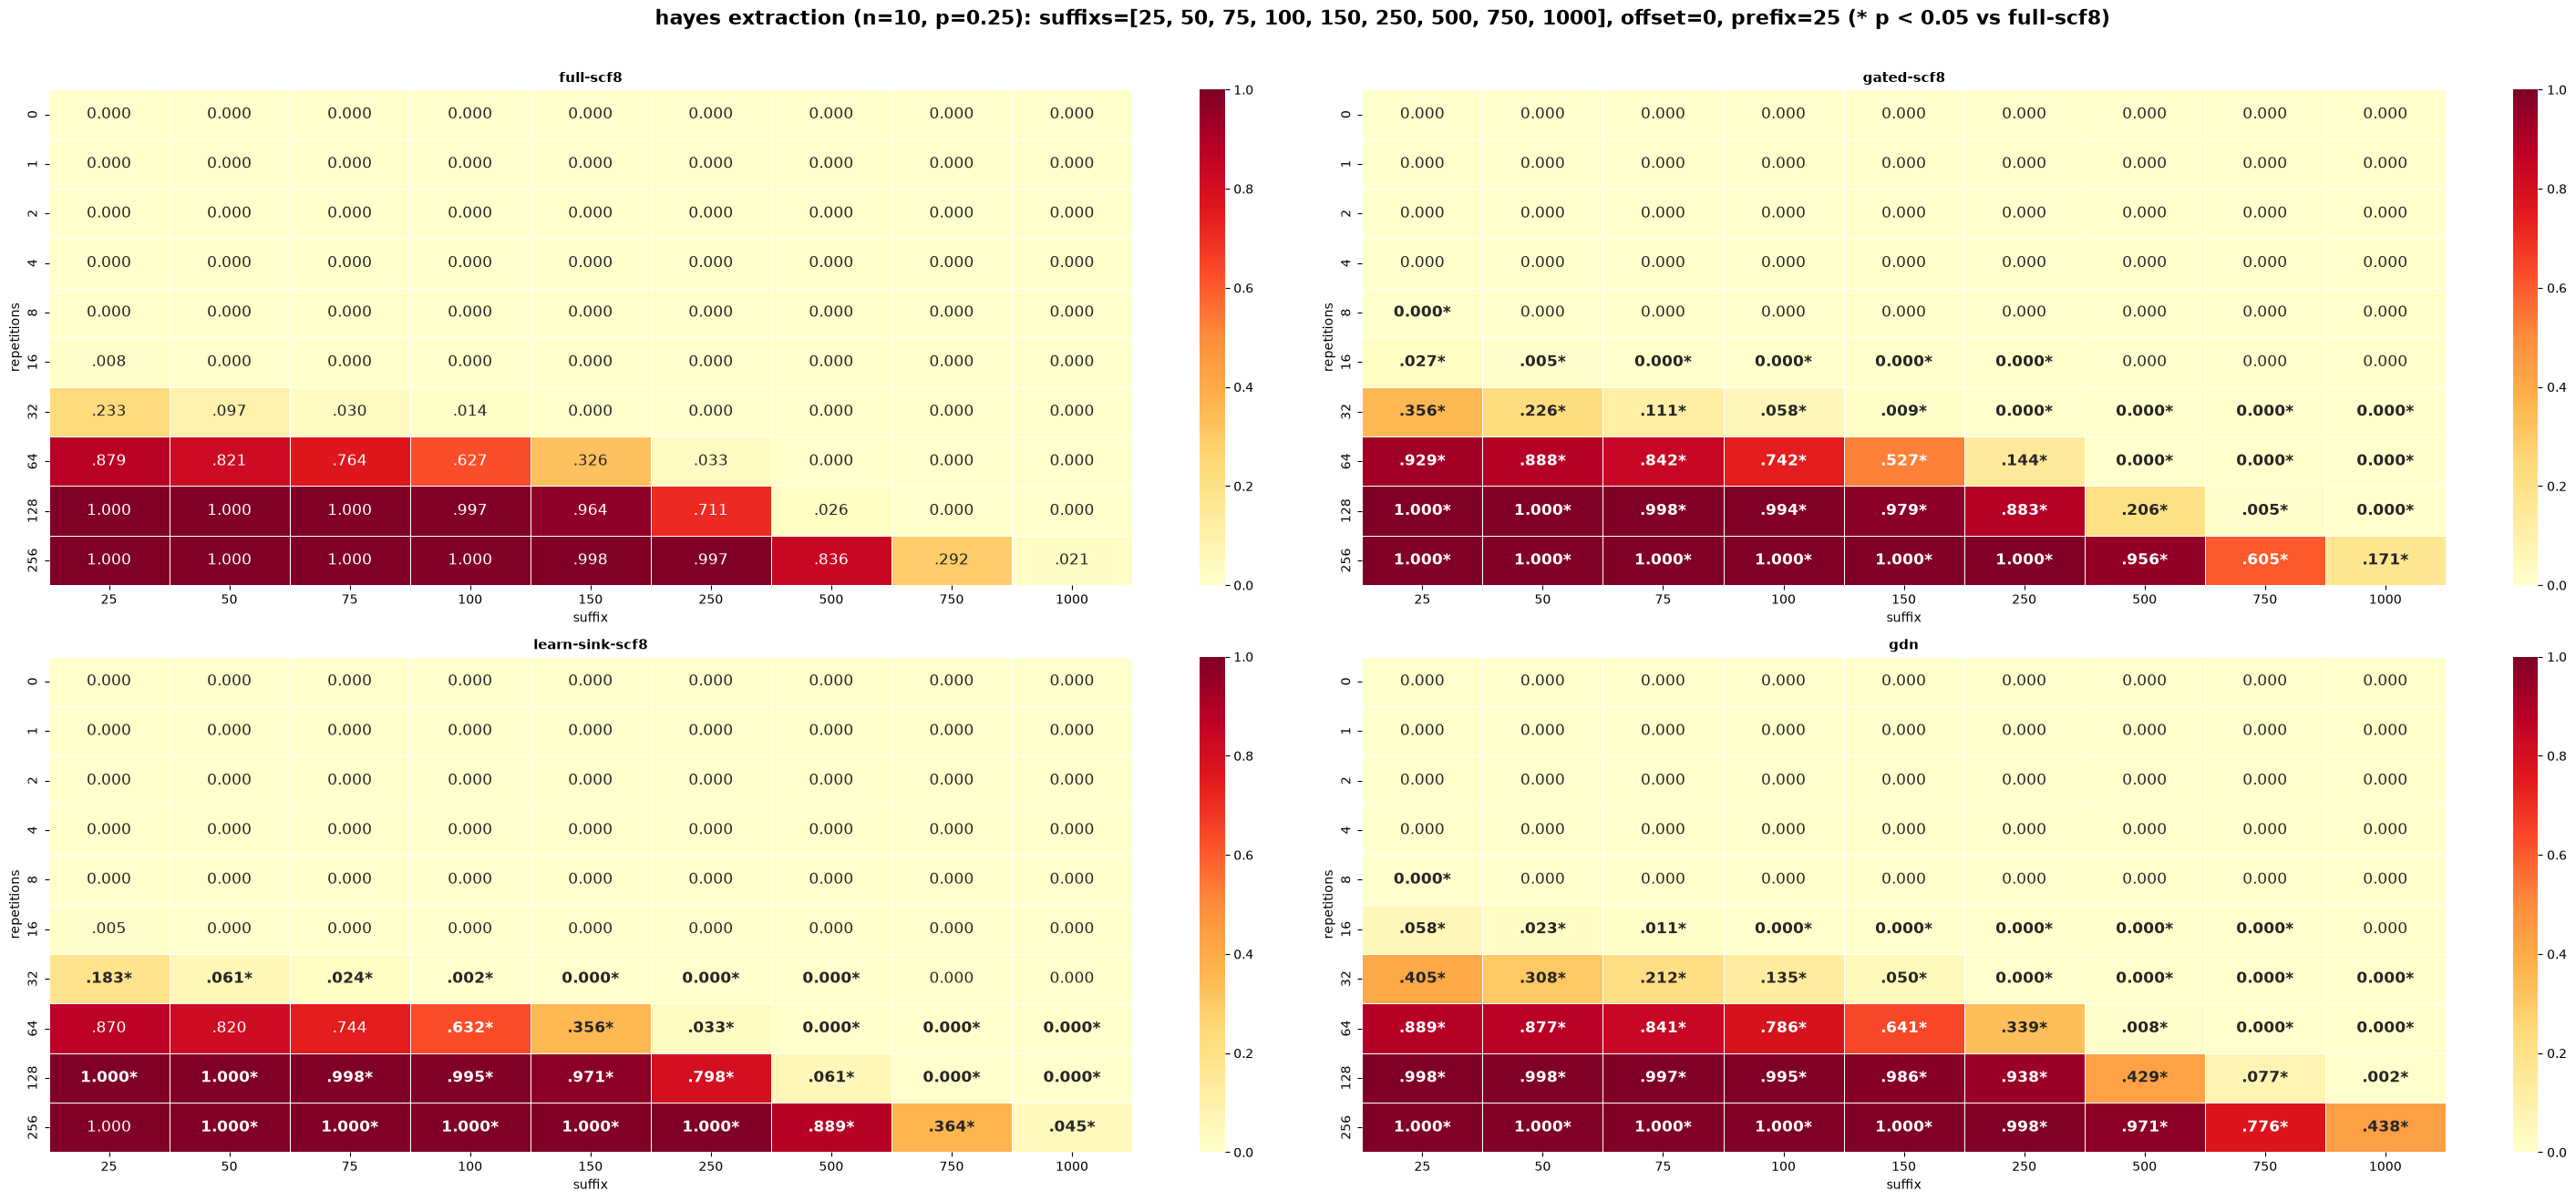

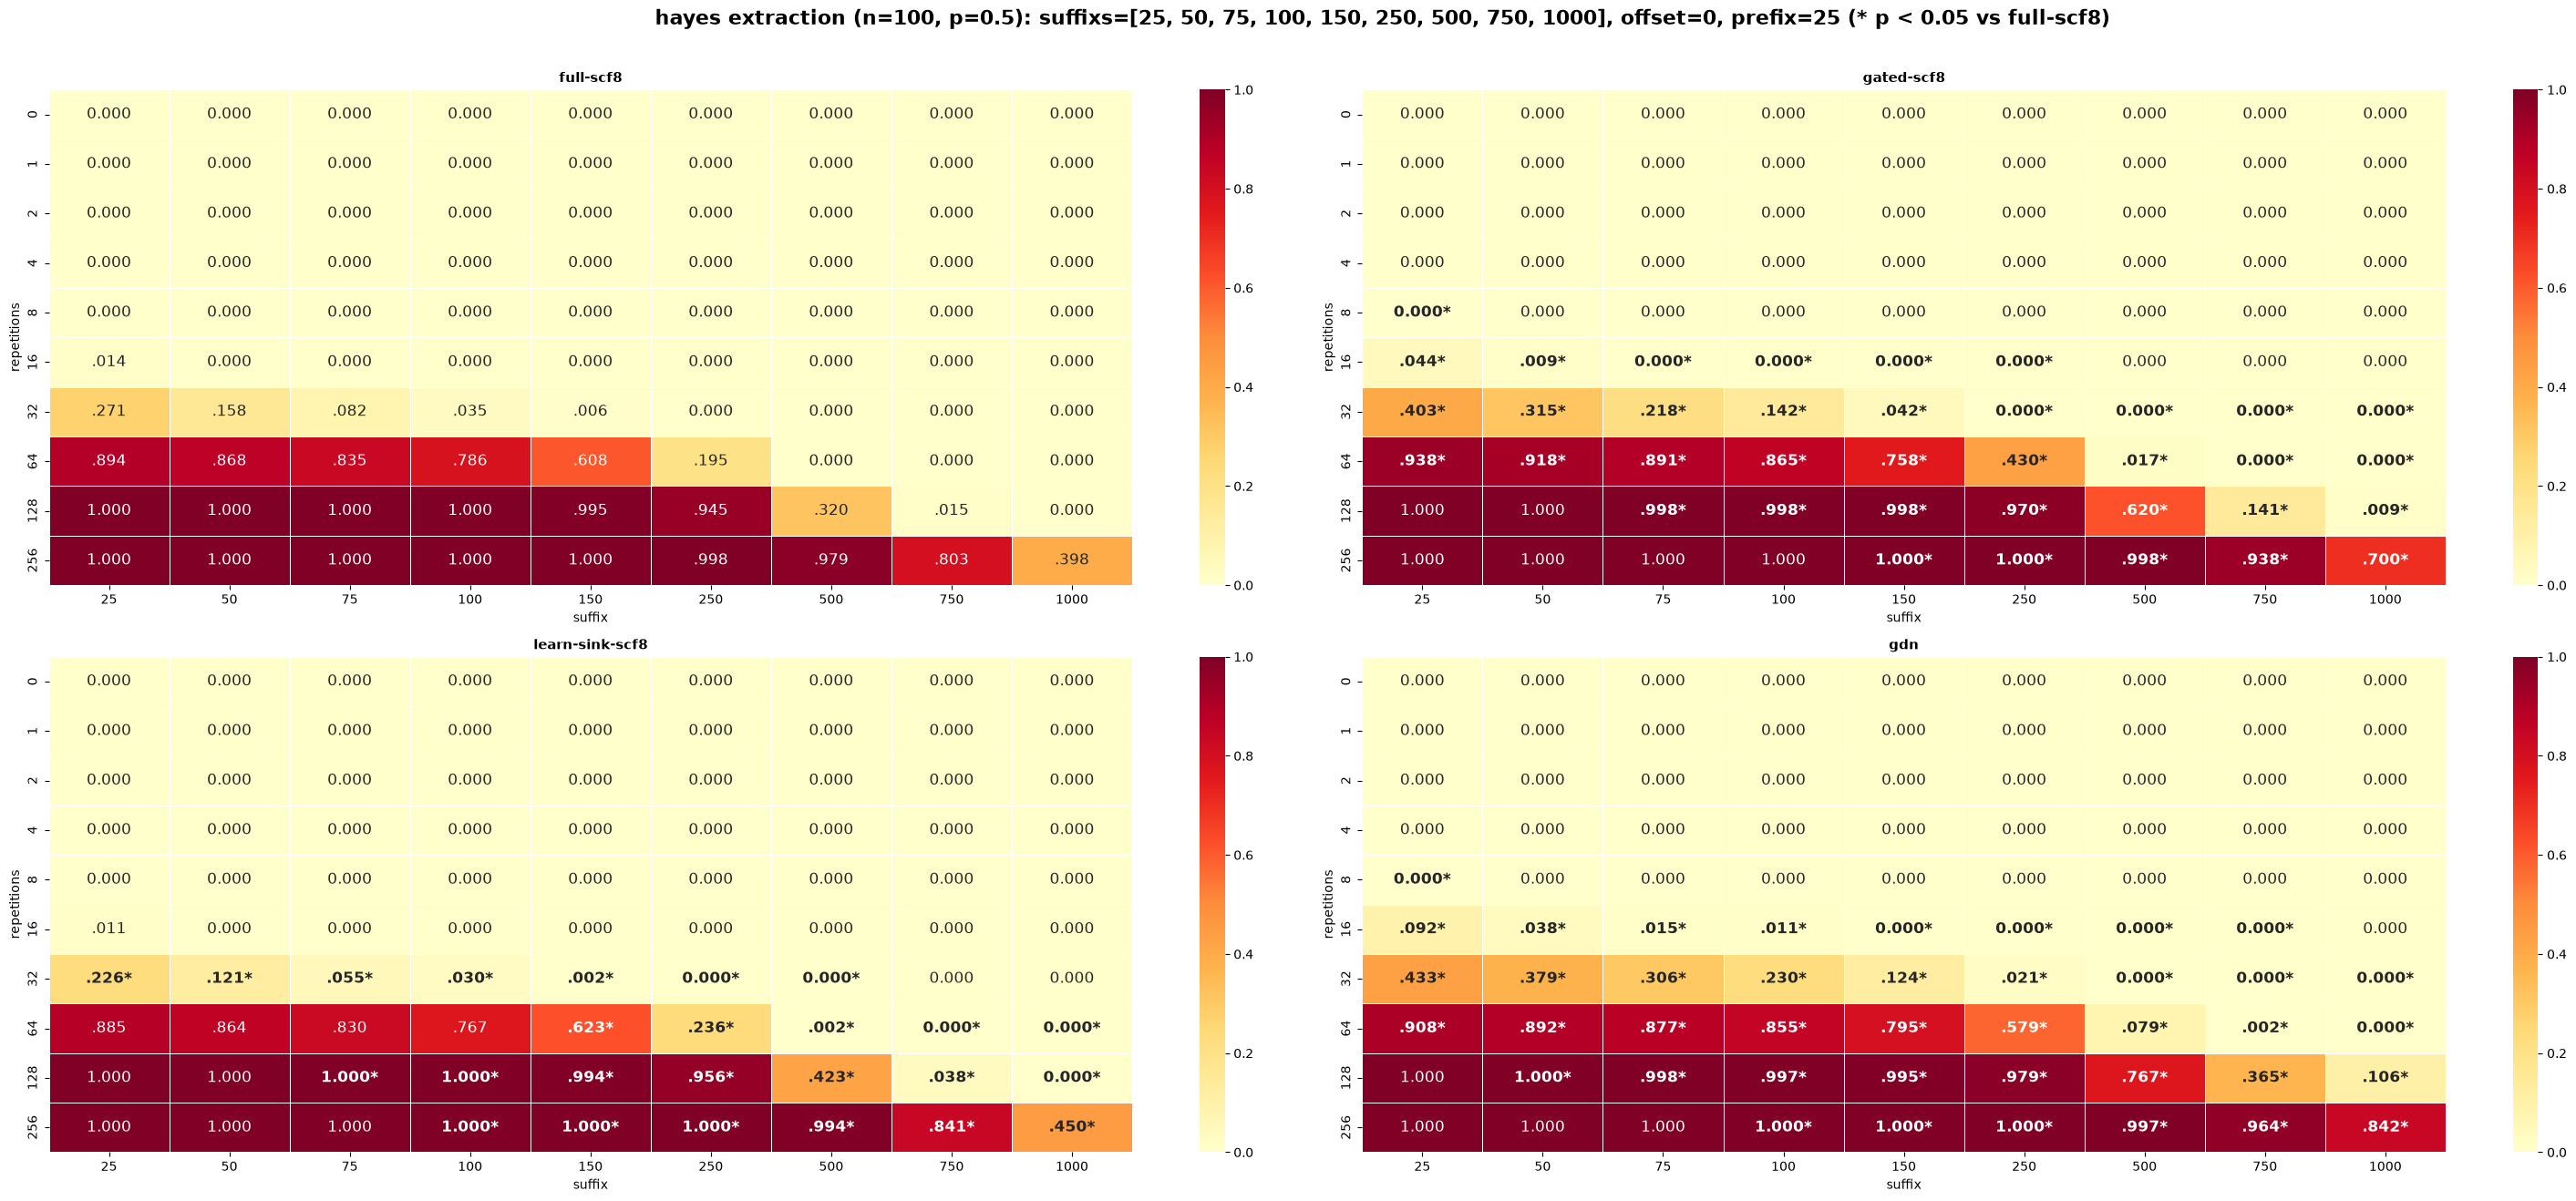

In [9]:
for n, p in N_P_COMBOS:
    plot_heatmap_per_model_panel(
        main_results_grid, 'hayes', columns='suffix', values=MAIN_SUFFIXES, fixed_offset=0, fixed_prefix=25,
        reference='full-scf8', show_pvalues=False, models=MAIN_MODELS, n=n, p=p, ncols=2
    )